# 准备数据

In [ ]:

import warnings
warnings.filterwarnings("ignore", category=FutureWarning)
import polars as pl

from vnpy.trader.constant import Interval

from vnpy.alpha import AlphaLab

In [ ]:
# 设置任务参数
from examples.download_bars.download_bars import database


name = "300_mlp"
index_symbol: str = "000300.SSE"
start: str = "2007-01-01"
end: str = "2024-10-31"
interval: Interval = Interval.DAILY
extended_days: int = 100
lab_dir="./lab/csi300"

In [ ]:
# 创建数据中心
lab: AlphaLab = AlphaLab(lab_dir)

In [5]:
# 加载所有成分股代码
component_symbols: list[str] = lab.load_component_symbols(index_symbol, start, end)
print(component_symbols)

['002472.SZSE', '002634.SZSE', '002795.SZSE', '603329.SSE', '688138.SSE', '002081.SZSE', '002683.SZSE', '002384.SZSE', '600234.SSE', '301176.SZSE', '300393.SZSE', '000672.SZSE', '300903.SZSE', '301191.SZSE', '300918.SZSE', '603162.SSE', '600884.SSE', '601601.SSE', '300985.SZSE', '300632.SZSE', '002398.SZSE', '603126.SSE', '688078.SSE', '603859.SSE', '300501.SZSE', '000886.SZSE', '300576.SZSE', '301539.SZSE', '601975.SSE', '603567.SSE', '301133.SZSE', '000830.SZSE', '002703.SZSE', '300099.SZSE', '301528.SZSE', '000837.SZSE', '603022.SSE', '002976.SZSE', '300786.SZSE', '300755.SZSE', '301314.SZSE', '603200.SSE', '688589.SSE', '002835.SZSE', '000890.SZSE', '301557.SZSE', '002492.SZSE', '300946.SZSE', '688595.SSE', '300029.SZSE', '002102.SZSE', '603336.SSE', '603117.SSE', '600018.SSE', '300252.SZSE', '600206.SSE', '002274.SZSE', '603006.SSE', '000036.SZSE', '002783.SZSE', '002526.SZSE', '301607.SZSE', '300997.SZSE', '600416.SSE', '000858.SZSE', '300968.SZSE', '002057.SZSE', '601058.SSE', '

# 特征计算

In [6]:
# 加载模块
from datetime import datetime
from functools import partial

from vnpy.trader.constant import Interval

from vnpy.alpha.dataset import (
    AlphaDataset,
    process_drop_na,
    process_robust_zscore_norm,
    process_fill_na,
    process_cs_rank_norm,
    to_datetime
)
from vnpy.alpha.dataset.datasets.alpha_158 import Alpha158

In [7]:
# 加载成分股数据
component_symbols=component_symbols[:10]
df: pl.DataFrame = lab.load_bar_df(component_symbols, interval, start, end, extended_days)

In [8]:
# 设置数据时间段
train_period: tuple[str, str] = ("2007-01-01", "2020-12-31")
valid_period: tuple[str, str] = ("2021-01-01", "2021-12-31")
test_period: tuple[str, str] = ("2022-01-01", "2024-10-31")

In [9]:
# 创建数据集对象
dataset: AlphaDataset = Alpha158(
    df,
    train_period=train_period,
    valid_period=valid_period,
    test_period=test_period,
    period="d",
)

/home/lai/test_v1/vnpy/vnpy/alpha/dataset/utility.py:15: PerformanceWarning: Determining the column names of a LazyFrame requires resolving its schema, which is a potentially expensive operation. Use `LazyFrame.collect_schema().names()` to get the column names without this warning.
  last_name: str = lf.columns[-1]


In [10]:
# 添加数据预处理器

dataset.add_processor( partial(process_drop_na, names=["label"]))
dataset.add_processor(partial(process_cs_rank_norm, names=["label"]))

In [11]:
# 准备特征和标签数据
dataset.prepare_data( max_workers=15)

2025-10-31 19:59:18 开始计算 因子特征


  0%|          | 0/159 [00:00<?, ?it/s]

Feature calculation kup_2 took: 0.19858050346374512 seconds
Feature calculation roc_20 took: 0.0054035186767578125 seconds
Feature calculation kup took: 0.16298532485961914 seconds
Feature calculation roc_30 took: 0.002848386764526367 seconds
Feature calculation roc_60 took: 0.0027997493743896484 seconds
Feature calculation ma_5 took: 0.005281925201416016 seconds
Feature calculation ma_10 took: 0.0043070316314697266 seconds
Feature calculation ma_20 took: 0.004427194595336914 seconds
Feature calculation ma_30 took: 0.03690910339355469 seconds
Feature calculation ma_60 took: 0.028554201126098633 seconds
Feature calculation roc_10 took: 0.19172048568725586 seconds
Feature calculation std_5 took: 0.005417823791503906 seconds
Feature calculation std_10 took: 0.006659746170043945 seconds
Feature calculation std_20 took: 0.0036644935607910156 seconds
Feature calculation std_30 took: 0.005132436752319336 seconds
Feature calculation klow_2 took: 0.16793322563171387 seconds
Feature calculation 

  1%|          | 1/159 [00:02<06:05,  2.31s/it]

Feature calculation rank_30 took: 0.031107664108276367 seconds
Feature calculation rank_60 took: 0.029798269271850586 seconds
Feature calculation rsv_5 took: 0.005919933319091797 seconds
Feature calculation rsv_10 took: 0.004671573638916016 seconds
Feature calculation rsv_20 took: 0.004668235778808594 seconds
Feature calculation kmid took: 0.33690667152404785 seconds
Feature calculation rsv_30 took: 0.0044994354248046875 seconds
Feature calculation rsv_60 took: 0.01857304573059082 seconds
Feature calculation low_0 took: 0.2694282531738281 seconds
Feature calculation high_0 took: 0.27008533477783203 seconds


...

Feature calculation open_0 took: 0.3142375946044922 seconds
Feature calculation imax_5 took: 0.41639280319213867 seconds
Feature calculation imin_5 took: 0.40178561210632324 seconds
Feature calculation imax_60 took: 0.41307544708251953 seconds
Feature calculation corr_5 took: 0.01088714599609375 seconds
Feature calculation imax_20 took: 0.4224867820739746 seconds
Feature calculation imax_30 took: 0.4201631546020508 seconds
Feature calculation imin_30 took: 0.40466833114624023 seconds
Feature calculation imin_20 took: 0.41060352325439453 seconds
Feature calculation corr_10 took: 0.004769325256347656 seconds
Feature calculation imax_10 took: 0.43751001358032227 seconds
Feature calculation corr_20 took: 0.004791736602783203 seconds
Feature calculation imin_60 took: 0.4101080894470215 seconds
Feature calculation imin_10 took: 0.4237637519836426 seconds
Feature calculation corr_30 took: 0.0044863224029541016 seconds
Feature calculation corr_60 took: 0.004604339599609375 seconds
Feature calc

 94%|█████████▎| 149/159 [00:03<00:00, 78.89it/s]

Feature calculation wvma_5 took: 0.01256251335144043 seconds
Feature calculation wvma_10 took: 0.005028724670410156 seconds
Feature calculation wvma_20 took: 0.008962154388427734 seconds
Feature calculation wvma_30 took: 0.004768848419189453 seconds
Feature calculation wvma_60 took: 0.005547285079956055 seconds
Feature calculation imxd_60 took: 0.7336113452911377 seconds
Feature calculation vsump_5 took: 0.011959075927734375 seconds
Feature calculation vsump_10 took: 0.010875940322875977 seconds
Feature calculation vsump_20 took: 0.006345033645629883 seconds
Feature calculation vsump_30 took: 0.009805917739868164 seconds
Feature calculation vsump_60 took: 0.016795635223388672 seconds
Feature calculation vsumn_5 took: 0.01544046401977539 seconds


100%|██████████| 159/159 [00:03<00:00, 43.13it/s]


Feature calculation vsumn_10 took: 0.008344650268554688 seconds
Feature calculation vsumn_20 took: 0.0042994022369384766 seconds
Feature calculation vsumn_30 took: 0.004606723785400391 seconds
Feature calculation vsumn_60 took: 0.00908517837524414 seconds
Feature calculation vsumd_5 took: 0.00931549072265625 seconds
Feature calculation vsumd_10 took: 0.006635904312133789 seconds
Feature calculation vsumd_20 took: 0.0067996978759765625 seconds
Feature calculation vsumd_30 took: 0.007710695266723633 seconds
Feature calculation label took: 0.0034983158111572266 seconds
Feature calculation vsumd_60 took: 0.00868082046508789 seconds
2025-10-31 19:59:22 因子计算完成 | 数量: 159 | 耗时: 3.909s
2025-10-31 19:59:22 开始执行处理器链
2025-10-31 19:59:22 处理器[1] partial 完成 | 耗时: 0.001s
2025-10-31 19:59:22 处理器[2] partial 完成 | 耗时: 0.015s
2025-10-31 19:59:22 按周期切片缓存处理结果
2025-10-31 19:59:22 数据准备完成：处理一次、按周期缓存、去重存储


infer freq: None
Dropped 0.4% entries from factor data: 0.4% in forward returns computation and 0.0% in binning phase (set max_loss=0 to see potentially suppressed Exceptions).
max_loss is 100.0%, not exceeded: OK!
Quantiles Statistics


,min,max,mean,std,count,count %
factor_quantile,,,,,,
1.0,0.425640,1.722949,0.870648,0.114526,3584,14.547226
2.0,0.660442,1.274756,0.927936,0.082657,2464,10.001218
3.0,0.596963,1.324775,0.961347,0.085586,2035,8.259934
4.0,0.555017,1.766106,0.989789,0.106042,2487,10.094573
5.0,0.707542,1.451109,1.005904,0.080278,2608,10.585704
6.0,0.765653,1.539728,1.030672,0.082551,1375,5.581037
7.0,0.625518,1.938344,1.048843,0.114803,2001,8.121930
8.0,0.761124,1.857372,1.063245,0.095220,2521,10.232577
9.0,0.885535,2.006006,1.107930,0.093902,1978,8.028575


Returns Analysis


,1D,5D,10D
Ann. alpha,0.017,0.076,0.044
beta,-0.039,-0.003,0.000
Mean Period Wise Return Top Quantile (bps),-1.095,0.410,0.378
Mean Period Wise Return Bottom Quantile (bps),0.062,-3.863,-1.750
Mean Period Wise Spread (bps),-1.157,5.722,3.462


<Figure size 640x480 with 0 Axes>

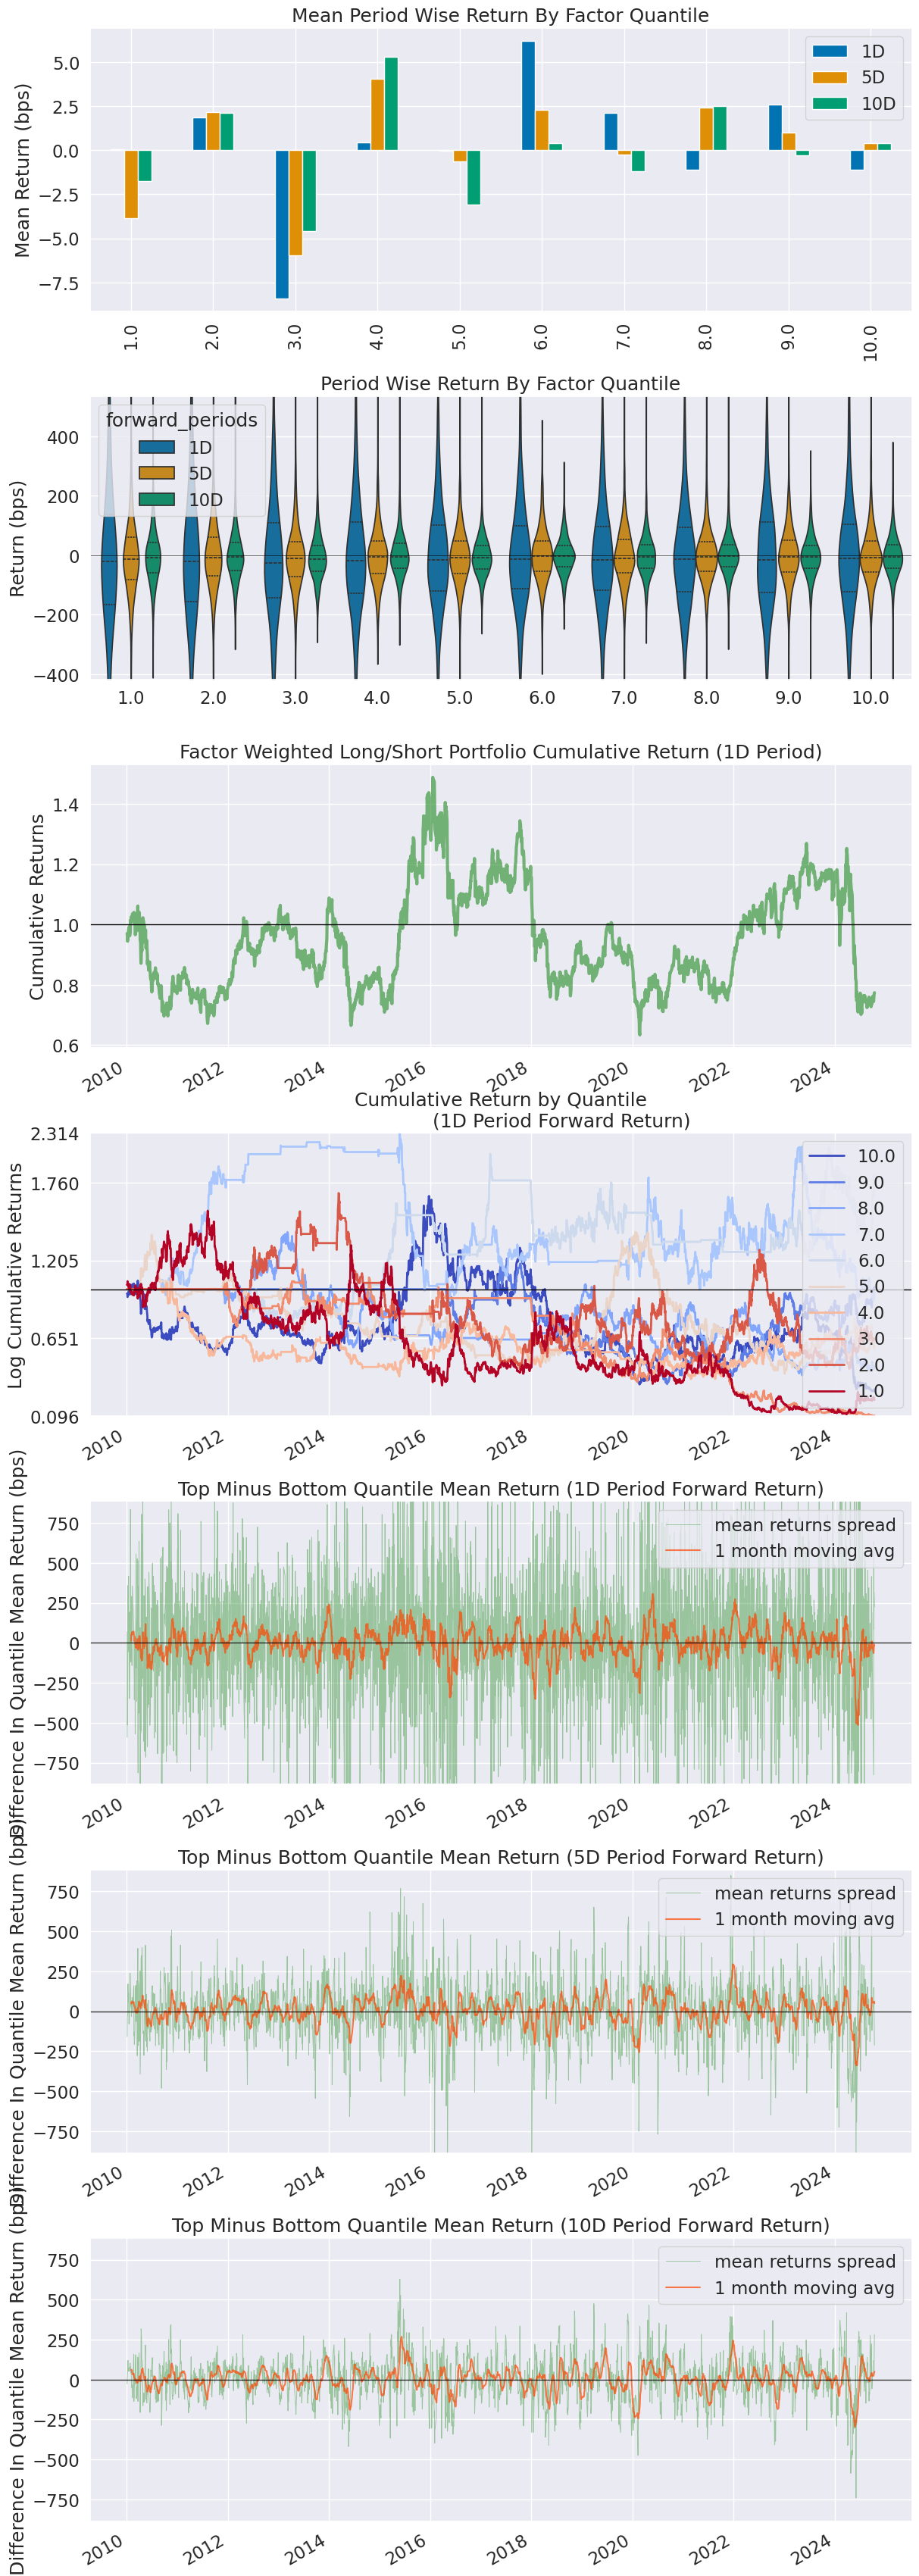

Information Analysis


,1D,5D,10D
IC Mean,0.026,0.033,0.032
IC Std.,0.489,0.485,0.481
Risk-Adjusted IC,0.054,0.067,0.066
t-stat(IC),NaN,NaN,NaN
p-value(IC),NaN,NaN,NaN
IC Skew,NaN,NaN,NaN
IC Kurtosis,NaN,NaN,NaN


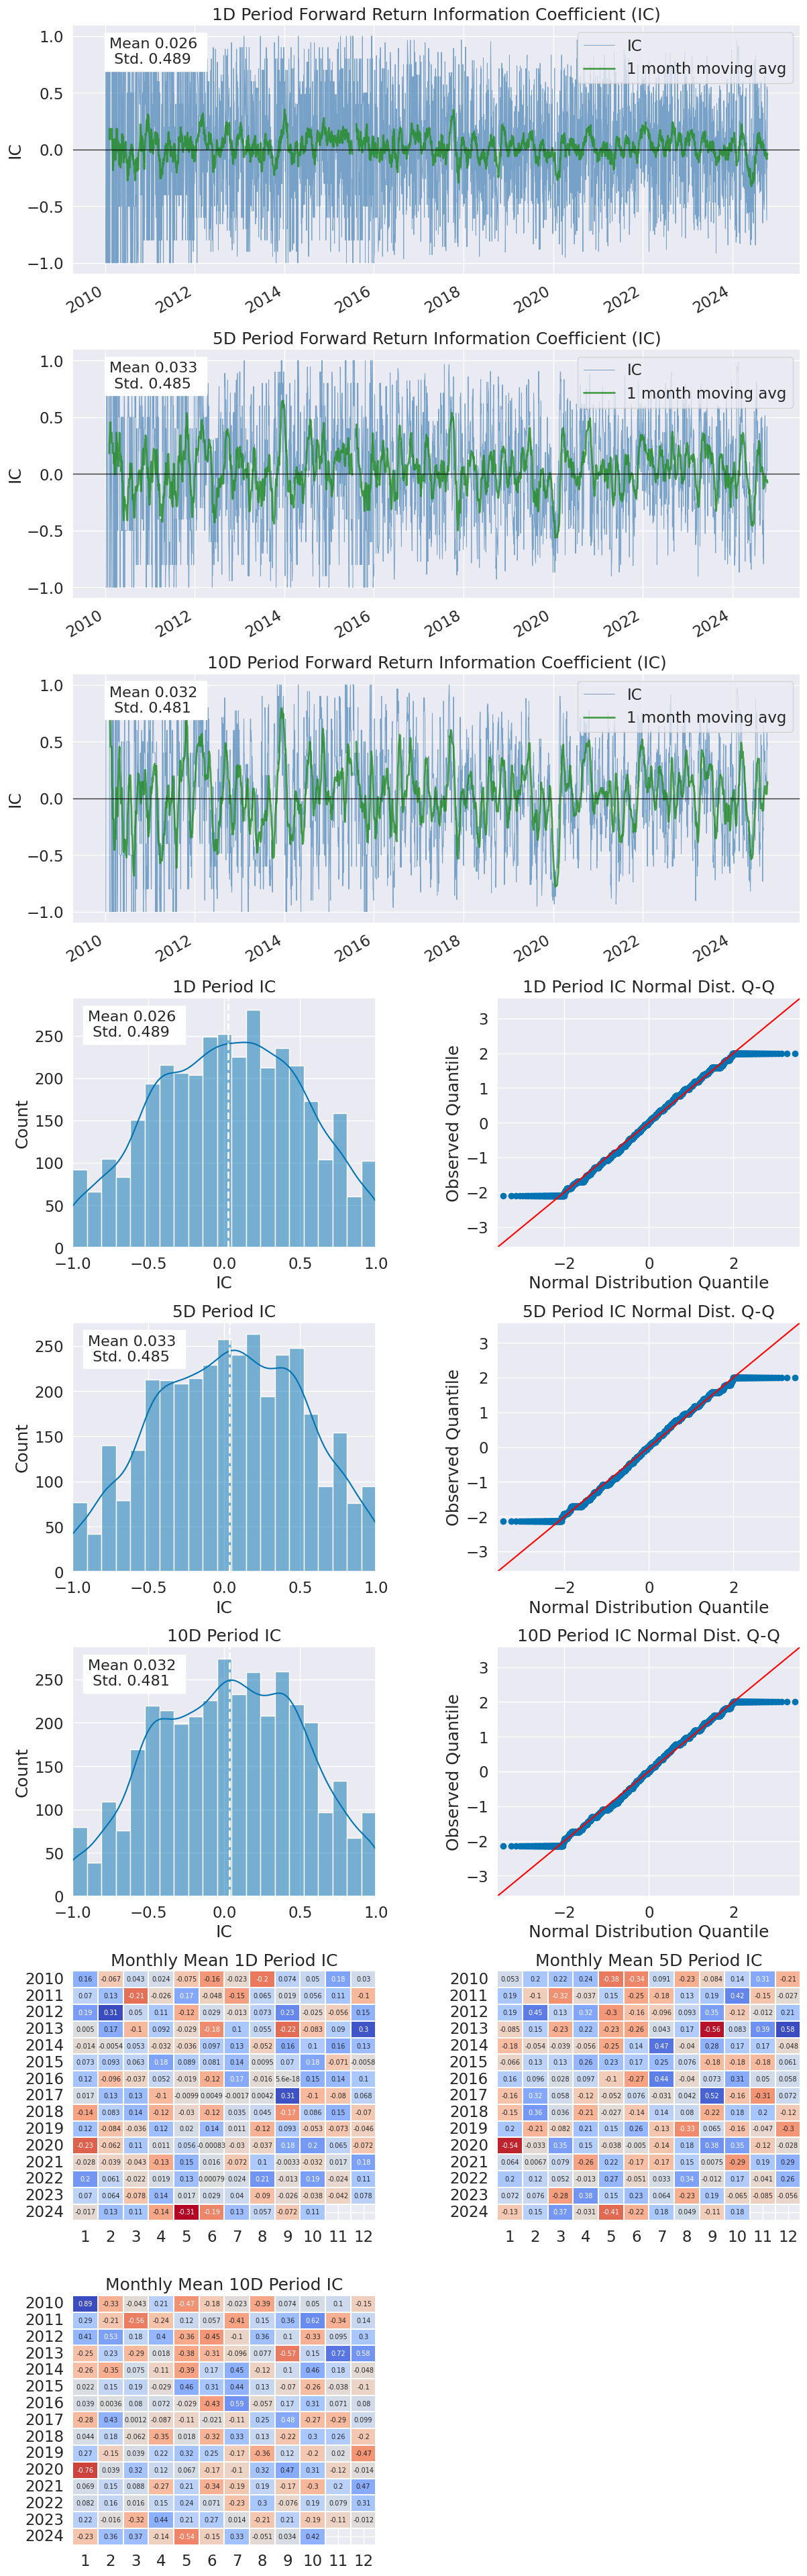

/home/lai/miniconda3/lib/python3.13/site-packages/alphalens/utils.py:928: UserWarning: Skipping return periods that aren't exact multiples of days.
  warnings.warn(


Turnover Analysis


,1D,5D,10D
Quantile 1.0 Mean Turnover,0.162,0.359,0.485
Quantile 2.0 Mean Turnover,0.345,0.603,0.720
Quantile 3.0 Mean Turnover,0.407,0.680,0.777
Quantile 4.0 Mean Turnover,0.442,0.694,0.764
Quantile 5.0 Mean Turnover,0.437,0.702,0.763
Quantile 6.0 Mean Turnover,0.439,0.706,0.759
Quantile 7.0 Mean Turnover,0.412,0.686,0.789
Quantile 8.0 Mean Turnover,0.385,0.640,0.726
Quantile 9.0 Mean Turnover,0.348,0.611,0.703
Quantile 10.0 Mean Turnover,0.158,0.343,0.471


,1D,5D,10D
Mean Factor Rank Autocorrelation,0.923,0.772,0.637


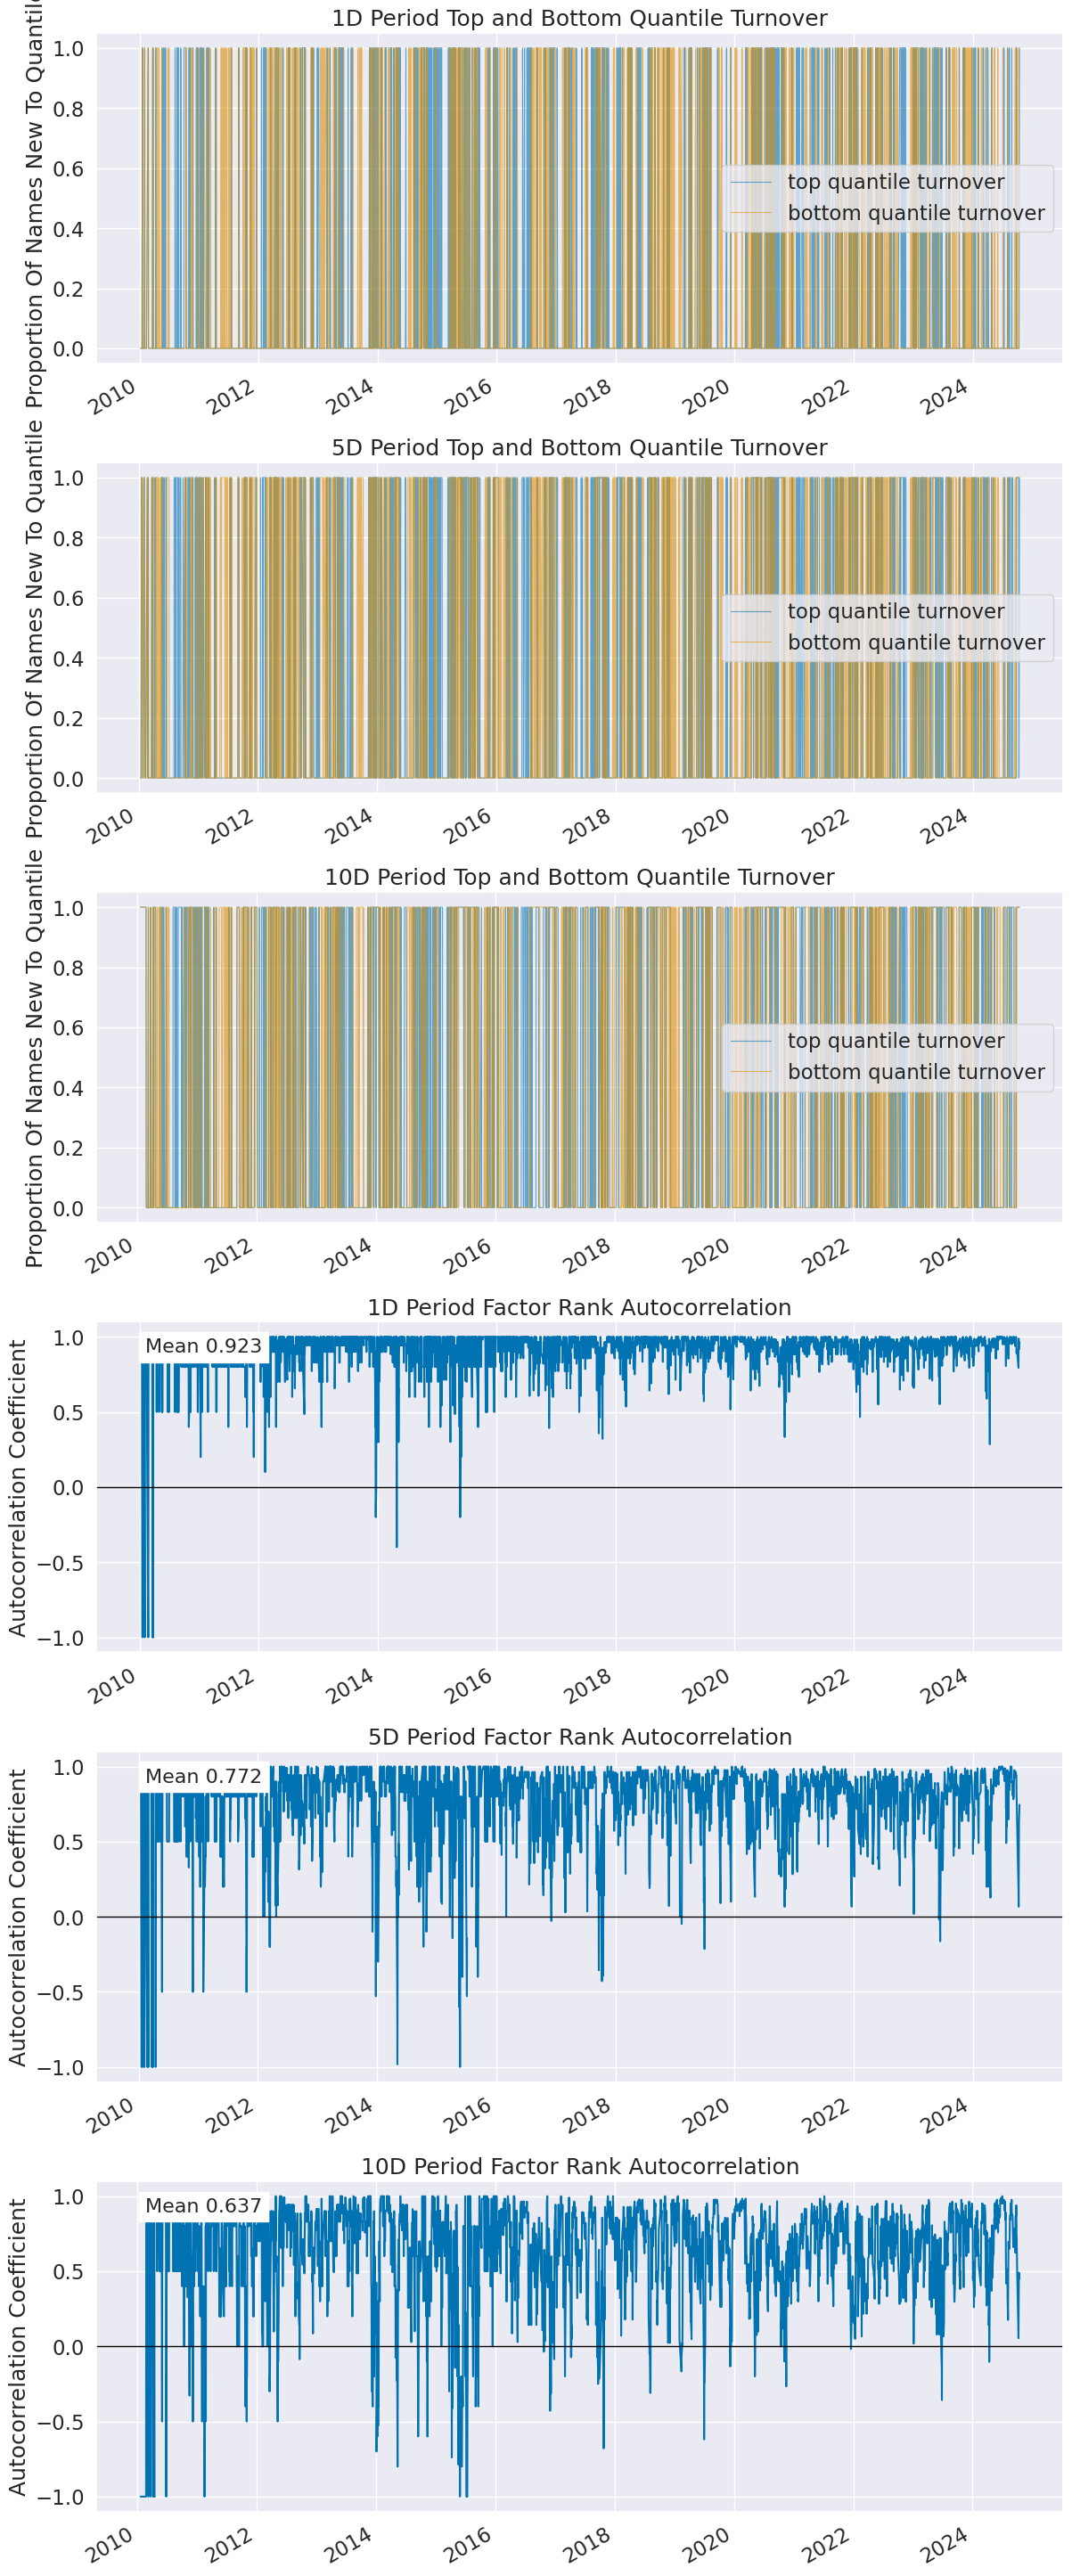

In [12]:
# 特征表现分析
dataset.show_feature_performance("ma_60")

In [13]:
dataset.df.shape

(24771, 10)

In [14]:
# 保存到文件缓存
lab.save_dataset(name, dataset)

# 模型训练

In [15]:
# 加载模块
import numpy as np

from vnpy.alpha import Segment, AlphaDataset, AlphaModel

from vnpy.alpha.model.models.mlp_model import MlpModel

In [16]:
# 从文件缓存加载
dataset: AlphaDataset = lab.load_dataset(name)

In [17]:
dataset.df.shape

(24741, 162)

In [18]:
# 创建模型对象
kwargs = {
    "input_size": 158,
    "hidden_sizes": (256,),
    "lr": 0.002,
    "optimizer": "adam",
    "n_epochs": 8000,
    "batch_size": 8192,
    "weight_decay": 0.0002,
    "seed": 42
}

model: AlphaModel = MlpModel(**kwargs)

In [19]:
from vnpy.alpha import Segment
df_train = dataset.fetch_feat(Segment.TRAIN)
print("TRAIN shape:", df_train.shape)
print(df_train.head())
print("TRAIN unique symbols:", df_train["vt_symbol"].unique()[:20])
print("TRAIN dates:", df_train["datetime"].min(), df_train["datetime"].max())

TRAIN shape: (15936, 162)
shape: (5, 162)
┌────────────────┬─────────────┬──────────┬───────────┬───┬──────────┬──────────┬──────────┬───────┐
│ datetime       ┆ vt_symbol   ┆ close    ┆ kmid      ┆ … ┆ vsumd_20 ┆ vsumd_30 ┆ vsumd_60 ┆ label │
│ ---            ┆ ---         ┆ ---      ┆ ---       ┆   ┆ ---      ┆ ---      ┆ ---      ┆ ---   │
│ datetime[μs]   ┆ str         ┆ f32      ┆ f32       ┆   ┆ f64      ┆ f64      ┆ f64      ┆ f64   │
╞════════════════╪═════════════╪══════════╪═══════════╪═══╪══════════╪══════════╪══════════╪═══════╡
│ 2010-01-04     ┆ 002081.SZSE ┆ 1.0      ┆ -0.01907  ┆ … ┆ NaN      ┆ NaN      ┆ NaN      ┆ 1.73  │
│ 00:00:00       ┆             ┆          ┆           ┆   ┆          ┆          ┆          ┆       │
│ 2010-01-04     ┆ 600234.SSE  ┆ 1.0      ┆ 0.00105   ┆ … ┆ NaN      ┆ NaN      ┆ NaN      ┆ 0.0   │
│ 00:00:00       ┆             ┆          ┆           ┆   ┆          ┆          ┆          ┆       │
│ 2010-01-05     ┆ 002081.SZSE ┆ 1.002616 ┆ 0.057

In [20]:
# 使用数据集训练模型
model.fit(dataset)

(15936, 162)
(2184, 162)
2025-10-31 19:59:44 开始训练模型, 总样本数: 15936


RuntimeError: mat1 and mat2 shapes cannot be multiplied (8192x159 and 158x256)

In [ ]:
# 查看模型细节
model.detail()

In [ ]:
# 保存模型
lab.save_model(name, model)

# 预测信号

In [ ]:
model: AlphaModel = lab.load_model(name)

In [ ]:
# 用模型在测试集上预测
pre: np.ndarray = model.predict(dataset, Segment.TEST)

# 加载测试集数据
df_t: pl.DataFrame = dataset.fetch_feat(Segment.TEST)

# 合并预测信号列
df_t = df_t.with_columns(pl.Series(pre).alias("signal"))

# 提取信号数据
signal: pl.DataFrame = df_t["datetime", "vt_symbol", "signal"]

In [ ]:
# 检查信号绩效
dataset.show_signal_performance(signal)

In [ ]:
# 保存信号数据
lab.save_signal(name, signal)

# 策略回测

In [ ]:
# 加载模块
import importlib
from datetime import datetime

from vnpy.alpha.strategy import BacktestingEngine

import vnpy.alpha.strategy.strategies.equity_demo_strategy as equity_demo_strategy

In [ ]:
# 重载策略类
importlib.reload(equity_demo_strategy)
EquityDemoStrategy = equity_demo_strategy.EquityDemoStrategy

In [ ]:
# 从文件加载信号数据
signal = lab.load_signal(name)

In [ ]:
# 创建回测引擎对象
engine = BacktestingEngine(lab)

# 设置回测参数
engine.set_parameters(
    vt_symbols=component_symbols,
    interval=Interval.DAILY,
    start=datetime(2022, 1, 1),
    end=datetime(2024, 10, 31),
    capital=100000000
)

# 添加策略实例
setting = {"top_k": 30, "n_drop": 3, "hold_thresh": 3}
engine.add_strategy(EquityDemoStrategy, setting, signal)

In [ ]:
# 执行回测任务
engine.load_data()
engine.run_backtesting()
engine.calculate_result()
engine.calculate_statistics()
engine.show_chart()

In [ ]:
# 显示超额收益分析结果
engine.show_performance(benchmark_symbol=index_symbol)